In [11]:
#Basic Libraries for the starting a Book
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [12]:
#ML Libraries 

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [13]:
sns.set_style("whitegrid")

In [14]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
df = pd.DataFrame(data.data , columns=data.feature_names)
df["target"] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [15]:
print("Shape:" , df.shape)
print("\nMisiing value:\n" , df.isnull().sum().sum())
print("\nTarget Distribution:\n", df["target"].value_counts())

Shape: (569, 31)

Misiing value:
 0

Target Distribution:
 target
1    357
0    212
Name: count, dtype: int64


In [16]:
#train test split 

X = df.drop("target" , axis= 1)
y = df["target"]

X_train , X_test , y_train , y_test = train_test_split(
    X,y,test_size=0.2,random_state =42
) 

print("Train shape:" , X_train.shape)
print("Test shape:" , X_test.shape)

Train shape: (455, 30)
Test shape: (114, 30)


In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_pred))

Logistic Regression Accuracy: 0.9736842105263158


In [19]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.9385964912280702


In [20]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

Decision Tree Accuracy: 0.9385964912280702


In [21]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9649122807017544


In [22]:
print("Logistic:", accuracy_score(y_test, log_pred))
print("Decision Tree:", accuracy_score(y_test, tree_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic: 0.9736842105263158
Decision Tree: 0.9385964912280702
Random Forest: 0.9649122807017544


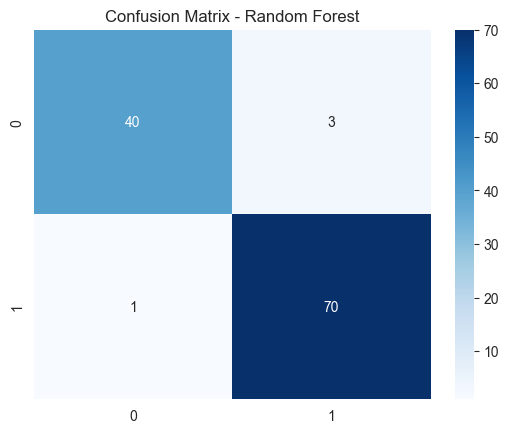

In [23]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [24]:
cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross Validation Scores: [0.92105263 0.94736842 0.98245614 0.96491228 0.97345133]
Mean CV Score: 0.9578481602235677
